Please refer to [Neural Tangents](https://github.com/google/neural-tangents) for dependencies.  
You may need [JAX with GPU Support](https://jax.readthedocs.io/en/latest/installation.html#install-nvidia-gpu).

In [2]:
from jax import random
from neural_tangents import stax
import jax.numpy as jnp
import neural_tangents as nt

from matplotlib import pyplot as plt

import dataloaders

2024-08-10 17:25:18.097328: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-10 17:25:18.114798: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-10 17:25:18.120204: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-10 17:25:18.842601: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
import importlib
importlib.reload(dataloaders)

<module 'dataloaders' from '/home/zhang/RP_ML/Active-learning-features/refactored-aaai25/dataloaders/__init__.py'>

In [4]:
#########################################
# Network definition

hidden_dim = 2048
in_dim = 1

init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(hidden_dim, W_std=2.0, b_std=0.05), stax.Erf(),# stax.Erf(),
    stax.Dense(hidden_dim, W_std=2.0, b_std=0.05), stax.Erf(),# stax.Erf(),
    # stax.Dense(hidden_dim, W_std=1.5, b_std=0.05), stax.Erf(),# stax.Erf(),
    # stax.Dense(hidden_dim, W_std=1.5, b_std=0.05), stax.Erf(),# stax.Erf(),
    # stax.Dense(hidden_dim, W_std=1.5, b_std=0.05), stax.Erf(),# stax.Erf(),
    stax.Dense(1)
)

key = random.PRNGKey(1)
# x = random.normal(key, (10, 1))

#########################################
# Data generation

ntx = dataloaders.get_train_X(N = 5)
nvx = dataloaders.get_val_X(N = 256)

x_tr = jnp.array(ntx)[:, None]
x_va = jnp.array(nvx)[:, None]
y_tr = jnp.array(dataloaders.get_Y(ntx, 0.03))[:, None]
y_va = jnp.array(dataloaders.get_Y(nvx))[:, None]

_, params = init_fn(key, input_shape=x_tr.shape)

2024-08-10 17:25:22.430896: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.6.20). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [5]:
################### Direct computation of Linearized dynamics on MSE #####################

predict_fn = nt.predict.gradient_descent_mse_ensemble(kernel_fn, x_tr, y_tr, diag_reg = 1e-3)
# y_val_nngp = predict_fn(x_test = x_va, get = 'nngp')

y_val_ntk, y_val_ntk_cov = predict_fn(x_test = x_va, get = 'ntk', compute_cov = True)
# y_val_ntk = predict_fn(x_test = x_va, get = 'nngp', compute_cov = True)

y = apply_fn(params, x_va)
y_var = kernel_fn(x_va, x_va, 'nngp')

# print(x_va)
# print(y_val_ntk)

ntk_mean = jnp.reshape(y_val_ntk, (-1,))
ntk_std = jnp.sqrt(jnp.diag(y_val_ntk_cov))

cov_scale = 2
y_lower = ntk_mean - ntk_std * cov_scale
y_upper = ntk_mean + ntk_std * cov_scale

In [6]:
##################### Upper bound by Gronwall Inequality ######################

Ozz = jnp.diag(kernel_fn(x_va, x_va, 'ntk'))
Oxx = jnp.diag(kernel_fn(x_tr, x_tr, 'ntk'))
Ozx = kernel_fn(x_va, x_tr, 'ntk')

addition_term = jnp.min(Oxx[None, :] - 2 * Ozx, axis = 1)
UB = Ozz + addition_term

# UB = 0.2 * jnp.exp(2 * jnp.sqrt(UB) - 1)
UB = 0.6 * jnp.sqrt(UB)

mean_term = jnp.mean(Oxx[None, :] - 2 * Ozx, axis = 1)
UB_mean = Ozz + mean_term

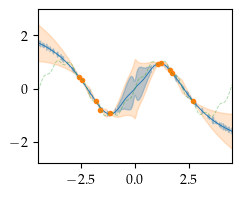

In [8]:
############################### VISUALIZATION #################################
plt.style.use('./aaai25.mplstyle')
plt.tight_layout()
# plt.figure(figsize = (14, 10))

plt.xlim(-4.5, 4.5)

# plt.fill_between(x_va[:, 0], ntk_mean - Ozz, ntk_mean + Ozz, alpha = 0.04, color = 'C3', label = "O(z,z)")
# plt.fill_between(x_va[:, 0], ntk_mean - UB_mean, ntk_mean + UB_mean, alpha = 0.14, color = 'C0', label = "Upper bound (mean)")
plt.fill_between(x_va[:, 0], ntk_mean - UB, ntk_mean + UB, alpha = 0.2, color = 'C1', label = "Upper bound")
plt.fill_between(x_va[:, 0], y_lower, y_upper, alpha = 0.3, color = 'C0', label = "Exact trained ensemble")

plt.plot(x_va[:, 0], ntk_mean, linewidth=0.65, label = "trained")
plt.plot(x_tr[:, 0], y_tr[:, 0], 'o', markersize=3, label = "dataset")
plt.plot(x_va[:, 0], y_va[:, 0], '--', linewidth=0.65, alpha = 0.4, label = "target")

# plt.legend()
# plt.savefig("test.png", dpi=300)
plt.savefig("test.pdf", format="pdf")
# plt.show()